In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, cohen_kappa_score, roc_auc_score, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121, ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback

# Configurations
DATA_DIR = './data/aptos2019-blindness-detection'
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train_images')
SAVE_MODEL_DIR = './checkpoints'
RESULTS_CSV_PATH = './results_comparison.csv'
os.makedirs(SAVE_MODEL_DIR, exist_ok=True)


In [ ]:
def crop_black_borders(image):
    """Crop non-informative black padding from fundus images."""
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        if w > 20 and h > 20:
            return image[y:y+h, x:x+w]
    return image

def preprocess_and_resize(image_path, target_size=(224, 224)):
    img = cv2.imread(image_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = crop_black_borders(img)
    img = cv2.resize(img, target_size)
    return img


In [ ]:

import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, cohen_kappa_score, roc_auc_score, precision_recall_curve
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121, ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from sklearn.utils.class_weight import compute_class_weight

print("OpenCV version:", cv2.__version__)
print("TensorFlow version:", tf.__version__)

from google.colab import drive
drive.mount('/content/drive')

data_path = './data/aptos2019-blindness-detection'
train_images_path = os.path.join(data_path, 'train_images')
train_csv_path = os.path.join(data_path, 'train.csv')
save_model_path = './models'
results_csv_path = './ketqua.csv'

if not os.path.exists(save_model_path):
    os.makedirs(save_model_path)

if not os.path.exists(train_csv_path):
    raise FileNotFoundError(f"Không tìm thấy file {train_csv_path}")
train_df = pd.read_csv(train_csv_path)

print("\nSố lượng ảnh theo nhãn (diagnosis):")
print(train_df['diagnosis'].value_counts().sort_index())

train_df['id_code'] = train_df['id_code'].apply(lambda x: x + '.png')
train_df['diagnosis'] = train_df['diagnosis'].astype(str)

def crop_black_borders(image):
    if image is None or image.size == 0:
        raise ValueError("Ảnh đầu vào không hợp lệ hoặc rỗng")
    if image.dtype == np.float32 or image.dtype == np.float64:
        image = (image * 255).astype(np.uint8)
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cnt = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(cnt)
        if w > 50 and h > 50:
            return image[y:y+h, x:x+w]
    return image

def apply_clahe(image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def preprocess_image(image, target_size=(224, 224)):
    try:
        image = crop_black_borders(image)
        image = apply_clahe(image)
        image = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)
        image = image.astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = (image - mean) / std
        return image
    except Exception as e:
        print(f"Lỗi trong preprocess_image: {e}")
        return None

def display_preprocessed_images(df, image_dir, num_images=3):
    sample_df = df.sample(n=num_images, random_state=42)
    plt.figure(figsize=(15, 5 * num_images))

    for idx, row in enumerate(sample_df.itertuples()):
        img_path = os.path.join(image_dir, row.id_code)
        img = cv2.imread(img_path)
        if img is None:
            print(f"Không thể đọc ảnh: {img_path}")
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_processed = preprocess_image(img.copy())
        if img_processed is None:
            print(f"Không thể tiền xử lý ảnh: {img_path}")
            continue

        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_display = (img_processed * std + mean) * 255.0
        img_display = np.clip(img_display, 0, 255).astype(np.uint8)

        plt.subplot(num_images, 2, 2 * idx + 1)
        plt.imshow(img)
        plt.title(f"Ảnh gốc: {row.id_code}\nNhãn: {row.diagnosis}")
        plt.axis('off')

        plt.subplot(num_images, 2, 2 * idx + 2)
        plt.imshow(img_display)
        plt.title(f"Ảnh sau tiền xử lý: {row.id_code}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

print("\nHiển thị ảnh trước và sau tiền xử lý:")
display_preprocessed_images(train_df, train_images_path, num_images=3)

def predict_image(image_path, model, input_size=(224, 224)):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Không thể đọc ảnh từ {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_processed = preprocess_image(img, input_size)
    if img_processed is None:
        raise ValueError("Xử lý ảnh thất bại")
    img_processed = np.expand_dims(img_processed, axis=0)
    pred = model.predict(img_processed)[0]
    class_idx = np.argmax(pred)
    labels = {0: "Không bệnh", 1: "Rất nhẹ", 2: "Nhẹ", 3: "Nặng", 4: "Tăng sinh"}
    return labels[class_idx], pred[class_idx]

class LossHistory(Callback):
    def __init__(self):
        super(LossHistory, self).__init__()
        self.train_losses = []
        self.val_losses = []

    def on_epoch_end(self, epoch, logs=None):
        self.train_losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))

input_size = (224, 224)
preprocess_func = lambda x: preprocess_image(x, target_size=input_size)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_func,
    rotation_range=30,
    zoom_range=0.3,
    shear_range=0.3,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='constant',
    cval=0
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_func)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_func)

train_temp, test_df = train_test_split(train_df, test_size=0.2, stratify=train_df['diagnosis'], random_state=42)
train_df_split, val_df = train_test_split(train_temp, test_size=0.125, stratify=train_temp['diagnosis'], random_state=42)

total_samples = len(train_df)
print(f"\nTổng số mẫu: {total_samples}")
print(f"Tập train: {len(train_df_split)} mẫu ({len(train_df_split)/total_samples*100:.1f}%)")
print(f"Tập validation: {len(val_df)} mẫu ({len(val_df)/total_samples*100:.1f}%)")
print(f"Tập test: {len(test_df)} mẫu ({len(test_df)/total_samples*100:.1f}%)")

train_df_balanced = train_df_split

print("\nSố lượng mỗi nhãn trong tập train:", train_df_balanced['diagnosis'].value_counts())
print("Số lượng mỗi nhãn trong tập validation:", val_df['diagnosis'].value_counts())
print("Số lượng mỗi nhãn trong tập test:", test_df['diagnosis'].value_counts())

class_weights = compute_class_weight('balanced', classes=np.array(['0', '1', '2', '3', '4']), y=train_df_balanced['diagnosis'])
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict[3] *= 1.5
class_weight_dict[4] *= 1.5

models = {'DenseNet121': DenseNet121, 'ResNet50': ResNet50}
results = {}
histories = {'DenseNet121': None, 'ResNet50': None}
optimal_thresholds = {'DenseNet121': {'class_1': None, 'class_3': None, 'class_4': None}, 'ResNet50': {'class_1': None, 'class_3': None, 'class_4': None}}

for model_name, model_func in models.items():
    print(f"\nHuấn luyện {model_name}...")
    train_generator = train_datagen.flow_from_dataframe(
        dataframe=train_df_balanced,
        directory=train_images_path,
        x_col='id_code',
        y_col='diagnosis',
        target_size=input_size,
        batch_size=32,
        class_mode='categorical'
    )
    val_generator = val_datagen.flow_from_dataframe(
        dataframe=val_df,
        directory=train_images_path,
        x_col='id_code',
        y_col='diagnosis',
        target_size=input_size,
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )
    test_generator = test_datagen.flow_from_dataframe(
        dataframe=test_df,
        directory=train_images_path,
        x_col='id_code',
        y_col='diagnosis',
        target_size=input_size,
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    base_model = model_func(weights='imagenet', include_top=False, input_shape=(*input_size, 3))
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.5)(x)
    x = Dense(5, activation='softmax')(x)  
    model = Model(inputs=base_model.input, outputs=x)

    for layer in base_model.layers:
        layer.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-2),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
    early_stopping = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
    history = LossHistory()
    model.fit(train_generator,
              validation_data=val_generator,
              epochs=2,
              callbacks=[early_stopping, reduce_lr, history],
              class_weight=class_weight_dict)

    for layer in base_model.layers:
        layer.trainable = True
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
    model.fit(train_generator,
              validation_data=val_generator,
              epochs=50,
              callbacks=[early_stopping, reduce_lr, history],
              class_weight=class_weight_dict)

    model.save(os.path.join(save_model_path, f'{model_name}_model.keras'))
    histories[model_name] = history

    y_pred_val = model.predict(val_generator)
    y_true_val = np.array(val_generator.classes)

    precision, recall, thresholds = precision_recall_curve(y_true_val == 1, y_pred_val[:, 1])
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    optimal_idx = np.argmax(f1_scores)
    optimal_thresholds[model_name]['class_1'] = thresholds[optimal_idx]
    print(f"Ngưỡng tối ưu cho lớp 1 ({model_name}): {optimal_thresholds[model_name]['class_1']}")

    precision, recall, thresholds = precision_recall_curve(y_true_val == 3, y_pred_val[:, 3])
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    optimal_idx = np.argmax(f1_scores)
    optimal_thresholds[model_name]['class_3'] = thresholds[optimal_idx]
    print(f"Ngưỡng tối ưu cho lớp 3 ({model_name}): {optimal_thresholds[model_name]['class_3']}")

    precision, recall, thresholds = precision_recall_curve(y_true_val == 4, y_pred_val[:, 4])
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    optimal_idx = np.argmax(f1_scores)
    optimal_thresholds[model_name]['class_4'] = thresholds[optimal_idx]
    print(f"Ngưỡng tối ưu cho lớp 4 ({model_name}): {optimal_thresholds[model_name]['class_4']}")

    print(f"\nĐánh giá {model_name} trên tập test...")
    y_pred = model.predict(test_generator)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_pred_classes[y_pred[:, 1] >= optimal_thresholds[model_name]['class_1']] = 1
    y_pred_classes[y_pred[:, 3] >= optimal_thresholds[model_name]['class_3']] = 3
    y_pred_classes[y_pred[:, 4] >= optimal_thresholds[model_name]['class_4']] = 4
    y_true = np.array(test_generator.classes)

    if not isinstance(y_true, np.ndarray):
        raise ValueError(f"y_true không phải là mảng NumPy: {type(y_true)}")

    cm = confusion_matrix(y_true, y_pred_classes)
    acc = np.mean(y_true == y_pred_classes)
    qwk = cohen_kappa_score(y_true, y_pred_classes, weights='quadratic')
    auc_per_class = []
    accuracy_per_class = []
    for i in range(5):
        true_binary = np.array(y_true == i, dtype=int)
        pred_scores = y_pred[:, i]
        auc_per_class.append(roc_auc_score(true_binary, pred_scores))
        accuracy_per_class.append(cm[i, i] / cm[i, :].sum() if cm[i, :].sum() > 0 else 0)
    macro_auc = np.mean(auc_per_class)

    results[model_name] = {
        'acc': acc,
        'qwk': qwk,
        'auc_per_class': auc_per_class,
        'macro_auc': macro_auc,
        'accuracy_per_class': accuracy_per_class,
        'cm': cm
    }

    print(f"Confusion Matrix {model_name}:\n", cm)
    print(f"Accuracy per class {model_name}:", accuracy_per_class)

plt.figure(figsize=(12, 5))
for model_name in models:
    plt.plot(histories[model_name].train_losses, label=f'{model_name} Train')
    plt.plot(histories[model_name].val_losses, label=f'{model_name} Val')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, model_name in enumerate(models):
    cm = results[model_name]['cm']
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f'Confusion Matrix - {model_name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(columns=['Model', 'Accuracy', 'QWK', 'AUC_0', 'AUC_1', 'AUC_2', 'AUC_3', 'AUC_4', 'Macro_AUC',
                                  'Accuracy_0', 'Accuracy_1', 'Accuracy_2', 'Accuracy_3', 'Accuracy_4'])
for model_name in results:
    row = {
        'Model': model_name,
        'Accuracy': results[model_name]['acc'],
        'QWK': results[model_name]['qwk'],
        'AUC_0': results[model_name]['auc_per_class'][0],
        'AUC_1': results[model_name]['auc_per_class'][1],
        'AUC_2': results[model_name]['auc_per_class'][2],
        'AUC_3': results[model_name]['auc_per_class'][3],
        'AUC_4': results[model_name]['auc_per_class'][4],
        'Macro_AUC': results[model_name]['macro_auc'],
        'Accuracy_0': results[model_name]['accuracy_per_class'][0],
        'Accuracy_1': results[model_name]['accuracy_per_class'][1],
        'Accuracy_2': results[model_name]['accuracy_per_class'][2],
        'Accuracy_3': results[model_name]['accuracy_per_class'][3],
        'Accuracy_4': results[model_name]['accuracy_per_class'][4]
    }
    results_df = pd.concat([results_df, pd.DataFrame([row])], ignore_index=True)

results_df.to_csv(results_csv_path, index=False)
print(f"Kết quả so sánh đã được lưu vào {results_csv_path}")

image_path = os.path.join(train_images_path, train_df['id_code'].iloc[0])
label, prob = predict_image(image_path, model)
print(f"Dự đoán cho ảnh {image_path}: {label} (xác suất: {prob:.4f})")



Kết quả phân loại 3 lớp

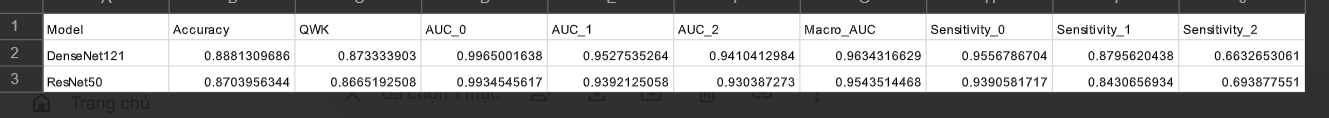

In [ ]:
Kết quả phân loại 5 lớp

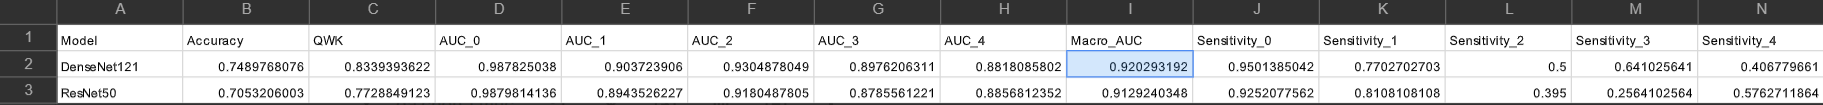